# Chapter 6 — Similarity, smoothing, and case-based prediction

*Companion notebook to **The Learned Kernel**, Ch. 6. Run top to bottom.*

A kernel machine predicts by **weighting historical cases**, so every prediction carries
its own evidence. Take the leaf kernel of Chapter 4 as the geometry and read its
Nadaraya–Watson smoother as a probability distribution over training rows:

ŷ(x) = Σᵢ wᵢ(x)·yᵢ,  wᵢ(x) = k(x,xᵢ)^ρ / Σ_r k(x,x_r)^ρ,  Σᵢ wᵢ(x)=1, wᵢ ≥ 0.

Because the weights are nonnegative and sum to one, the prediction *is* its explanation —
which cases it leaned on, and how much. From the same weights fall a per-query **evidence
ledger**: the effective sample size N_eff, the local label spread Δ_y, the teacher-fidelity
gap G_q, the local calibration residual C_cal, and the top-weighted **witnesses**.

**The frame** — *what is learned · how scored · what you read off.* The geometry is the
Chapter-4 leaf kernel (learned by the forest). It is scored on a held-out validation fold,
which picks the sharpening β and the blend ρ. You read off the witnesses, N_eff and the
trust flags behind every prediction.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import load_california, load_taiwan, set_style
from lkbook.chapters import ch06

set_style()
cal = load_california()
tw = load_taiwan()

## 6.1  Prediction as a distribution over cases

The leaf-kernel NW weights are nonnegative and sum to one, so the prediction is a convex
average of training labels — it lies in their hull, and it says which cases supported it.

In [3]:
cal_m = ch06.CaseBasedModel().fit(cal)
K = cal_m.kernel_rows(cal.Xte[:50])
W = ch06.nw_weights(K, topk=200, power=1.0)
print(f"weights nonnegative: {(W >= 0).all()}")
print(f"each row sums to one: {np.allclose(W.sum(1), 1.0)}")
pred = W @ cal_m.ytr
print(f"prediction in [min y, max y] hull: "
      f"{(pred >= cal_m.ytr.min() - 1e-9).all() and (pred <= cal_m.ytr.max() + 1e-9).all()}")

weights nonnegative: True
each row sums to one: True
prediction in [min y, max y] hull: True


## 6.2  How much evidence?  N_eff and Δ_y

N_eff(x) = 1 / Σᵢ wᵢ(x)² counts the cases that actually carry the prediction: n for uniform
weights, 1 for a one-hot weight. Δ_y(x) = Σᵢ wᵢ(x)(yᵢ − ȳ)² says whether they agree.

In [4]:
n = 200
uniform = ch06.nw_weights(np.ones((1, n)), topk=None)
onehot = ch06.nw_weights(np.eye(1, n, 7), topk=None)   # all mass on one case
print(f"uniform weights → N_eff = {1/np.sum(uniform**2):.1f}  (= n = {n})")
print(f"one-hot weight  → N_eff = {1/np.sum(onehot**2):.1f}  (= 1)")

uniform weights → N_eff = 200.0  (= n = 200)
one-hot weight  → N_eff = 1.0  (= 1)


## 6.3  Is the evidence trustworthy?  G_q, C_cal, and the fidelity bound

With teacher scores qᵢ (the Chapter-4 forest) the teacher-fidelity gap is
G_q(x) = |q(x) − Σᵢ wᵢ(x)·qᵢ|. Cauchy–Schwarz bounds it by the local-fidelity radius
(Σᵢ wᵢ(x)(qᵢ − q(x))²)^½ — the smoother matches the teacher when the teacher is stable
among similar cases. C_cal(x) = Σᵢ wᵢ(x)(yᵢ − qᵢ) measures local calibration.

In [5]:
q_query = cal_m._teacher(cal.Xte[:50])
g_q = np.abs(q_query - W @ cal_m.q_tr)
radius = ch06.fidelity_radius(K, cal_m.q_tr, q_query, topk=200, power=1.0)
print(f"G_q ≤ fidelity radius for all queries: {(g_q <= radius + 1e-9).all()}")

G_q ≤ fidelity radius for all queries: True


## 6.4  The full evidence ledger, and the witnesses

Every prediction comes with the literal cases behind it — the precedent it cites. Render
the ledger for one California query (the median-N_eff case, a typical well-supported one).

In [6]:
cal_run = ch06.run_dataset(cal)
ev = cal_run["evidence"]
print(f"California: selected β*={cal_run['power_star']}, ρ*={cal_run['rho_star']:.1f}, "
      f"median N_eff={cal_run['neff_median']:.0f}")
qcal = ch06.well_supported_query(ev)
print(ch06.format_ledger(cal, ev, qcal))

California: selected β*=8, ρ*=0.0, median N_eff=155
TREE-KERNEL LOCAL EVIDENCE LEDGER
  Empirical local mean:      +2.4017
  Teacher local mean:        +2.3218

  Diagnostics:
    N_eff (effective cases):   158.59
    Delta_y (local label var): 0.5233
    Delta_q (local teacher v): 0.2325
    G_q   (teacher fidelity):  0.0001
    Delta_K (kernel radius):   0.3362
    C_cal (local calibration): +0.0799

  Top 8 weighted witnesses (cum. weight 0.1065):
  ------------------------------------------------------------------
  rank     idx    weight         y         q        k      d_K
  ------------------------------------------------------------------
     1    2164    0.0157    4.2500    2.7531   0.9450   0.3317
     2     660    0.0138    1.6530    2.0368   0.9300   0.3742
     3    1002    0.0132    2.7110    2.4820   0.9250   0.3873
     4    2732    0.0132    2.1320    2.2481   0.9250   0.3873
     5    1628    0.0132    2.2000    2.0777   0.9250   0.3873
     6    1992    0.0132    1

The witness table is the audit artifact: each row is a real training case, its weight is
the citation strength, and `d_K` is the leaf-co-occupancy distance √(2(1−k)).

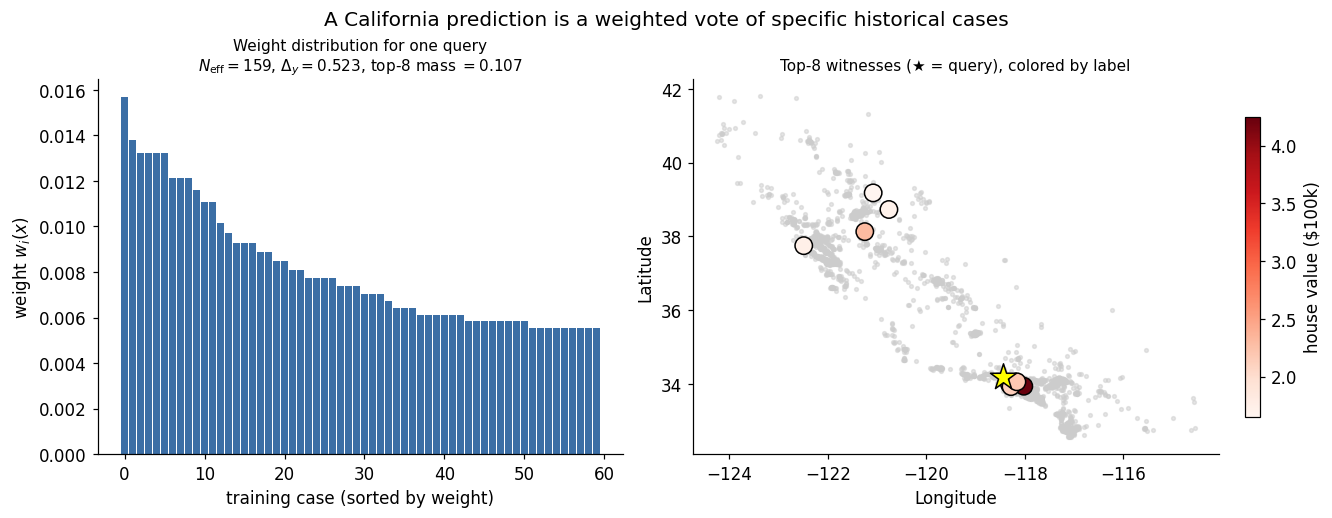

In [7]:
ch06.make_witness_figure(cal_run, cal)
plt.show()

## 6.5  Empirical vs teacher vs blended — and the noise-vs-blend finding

Three heads on **one** geometry: average observed labels, average the teacher's scores, or
blend zᵢ(ρ) = (1−ρ)yᵢ + ρ·qᵢ with ρ chosen on validation. The choice is a finding about the
data's noise: ρ*→0 on smooth California labels, ρ*→1 on noisy Taiwan defaults.

In [8]:
tw_run = ch06.run_dataset(tw)
rows = {
    "California (test RMSE)": {
        "empirical": round(cal_run["head_loss"]["empirical"], 3),
        "teacher": round(cal_run["head_loss"]["teacher"], 3),
        "blended": round(cal_run["head_loss"]["blended"], 3),
        "forest": round(cal_run["forest_loss"], 3),
        "ρ*": cal_run["rho_star"],
    },
    "Taiwan (test log-loss)": {
        "empirical": round(tw_run["head_loss"]["empirical"], 4),
        "teacher": round(tw_run["head_loss"]["teacher"], 4),
        "blended": round(tw_run["head_loss"]["blended"], 4),
        "forest": round(tw_run["forest_loss"], 4),
        "ρ*": tw_run["rho_star"],
    },
}
print(f"ρ* California {cal_run['rho_star']:.1f}  <  ρ* Taiwan {tw_run['rho_star']:.1f}"
      "  — same kernel machine, opposite blends, dictated by label noise.")
pd.DataFrame(rows).T

ρ* California 0.0  <  ρ* Taiwan 1.0  — same kernel machine, opposite blends, dictated by label noise.


,empirical,teacher,blended,forest,ρ*
California (test RMSE),0.6190,0.6330,0.6190,0.5300,0.0
Taiwan (test log-loss),0.4405,0.4396,0.4457,0.4478,1.0


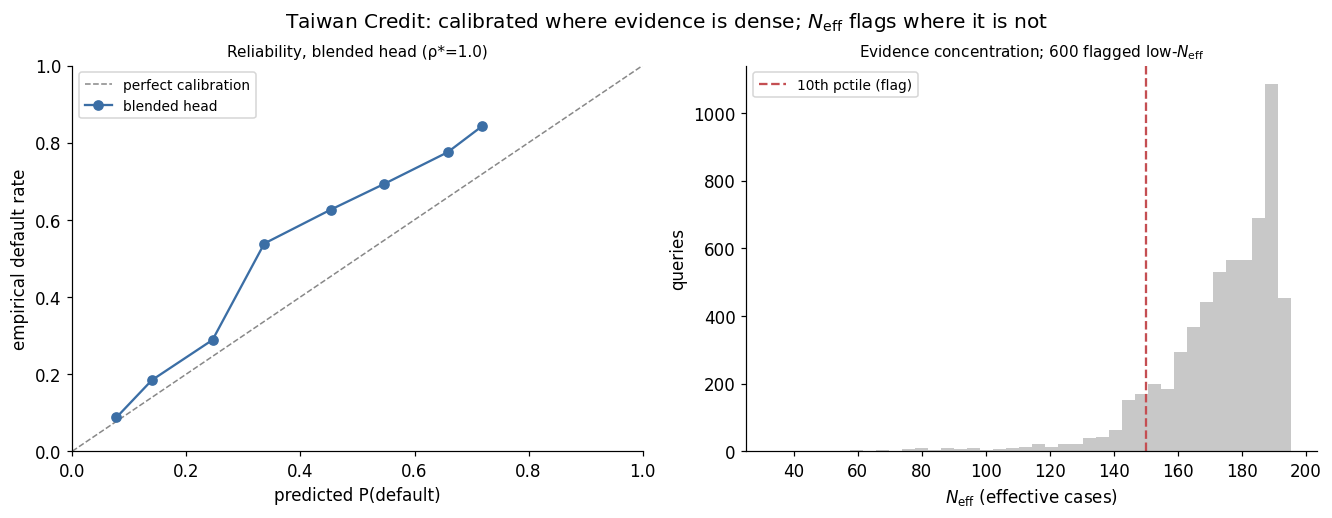

In [9]:
ch06.make_reliability_figure(tw_run, tw)
plt.show()

## 6.6  Explore one query's evidence

Move the query index and watch the ledger change: N_eff, the trust diagnostics, and the
weight tail. Switch the dataset to see California (smooth) vs Taiwan Credit (noisy).

In [10]:
from ipywidgets import interact, IntSlider, Dropdown

_runs = {"California": (cal_run, cal), "Taiwan Credit": (tw_run, tw)}


def explore(dataset="California", query=0):
    run, d = _runs[dataset]
    ev = run["evidence"]
    i = query % len(ev["neff"])
    fig, ax = plt.subplots(figsize=(7.5, 3.6), constrained_layout=True)
    W = ev["weights"][i]
    ax.bar(np.arange(50), np.sort(W)[::-1][:50], color="#3b6ea5")
    ax.set_xlabel("training case (sorted by weight)"); ax.set_ylabel("weight $w_i$")
    ax.set_title(f"{dataset} query {i}:  N_eff={ev['neff'][i]:.0f}  "
                 f"Δ_y={ev['delta_y'][i]:.3f}  G_q={ev['g_q'][i]:.3f}  "
                 f"C_cal={ev['c_cal'][i]:+.3f}")
    plt.show()
    print(ch06.format_ledger(d, ev, i))


interact(explore,
         dataset=Dropdown(options=list(_runs), value="California", description="data"),
         query=IntSlider(min=0, max=400, step=1, value=0, description="query"));

interactive(children=(Dropdown(description='data', options=('California', 'Taiwan Credit'), value='California'…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the NW weights are a probability distribution over cases, so the
prediction lies in the convex hull of the training labels.

In [11]:
# TODO: from W (6.1), check nonnegativity, row sums, and the hull containment of W @ ytr
nonneg = rowsum_ok = in_hull = None
print(nonneg, rowsum_ok, in_hull)

None None None


<details><summary>Solution</summary>

```python
nonneg = bool((W >= 0).all())
rowsum_ok = bool(np.allclose(W.sum(1), 1.0))
p = W @ cal_m.ytr
in_hull = bool((p >= cal_m.ytr.min()).all() and (p <= cal_m.ytr.max()).all())
print(nonneg, rowsum_ok, in_hull)   # True True True
```
Nonnegative, row-stochastic weights make the prediction a convex average — it cannot leave
the range of the observed labels.
</details>

**(medium)** Show N_eff = 1 exactly when one weight is one. Build a weight vector that
decays geometrically with rank and watch N_eff drop as the decay sharpens.

In [12]:
# TODO: for r in (1.0, 0.8, 0.5), build w ∝ r**arange(200), normalize, report N_eff
neffs = None
print(neffs)

None


<details><summary>Solution</summary>

```python
neffs = {}
for ratio in (1.0, 0.8, 0.5):
    w = ratio ** np.arange(200); w = w / w.sum()
    neffs[ratio] = float(1 / np.sum(w**2))
print(neffs)   # ratio=1 → 200 (uniform); sharper decay → smaller N_eff → 1 in the limit
```
N_eff = (Σw)²/Σw² = 1/Σw² for normalized w. It equals 1 iff all mass is on one case, and
equals n iff the weights are uniform; geometric decay interpolates between them.
</details>

**(⋆)** Verify the Cauchy–Schwarz local-fidelity bound and find where it is tight: for the
Taiwan ledger, compare G_q to the fidelity radius across the test set.

In [13]:
# TODO: compute G_q and the radius on tw, and the fraction where the bound holds
holds = tightness = None
print(holds, tightness)

None None


<details><summary>Solution</summary>

```python
K = tw_run["model"].kernel_rows(tw.Xte)
qq = tw_run["model"]._teacher(tw.Xte)
W = ch06.nw_weights(K, topk=tw_run["model"].topk, power=tw_run["model"].power)
g_q = np.abs(qq - W @ tw_run["model"].q_tr)
radius = ch06.fidelity_radius(K, tw_run["model"].q_tr, qq,
                              topk=tw_run["model"].topk, power=tw_run["model"].power)
holds = bool((g_q <= radius + 1e-9).all())
tightness = float(np.median(g_q / (radius + 1e-12)))   # near 1 when teacher is locally biased
print(holds, tightness)
```
The bound holds everywhere; it is tight when the teacher's deviation from the query score is
one-signed among the witnesses (a coherent local bias), loose when it averages out.
</details>

---
*Companion to Chapter 6 of **The Learned Kernel**. The NW smoother, the evidence ledger and
the three prediction heads come from `lkbook.chapters.ch06` — the same code the book's
figures are generated from. The leaf kernel is reused from `lkbook.chapters.ch04`.*